### ANOVA 분석
- 세 그룹 이상의 평균을 한 번에 비교함
- 상권 데이터
- 상권 유형은 4가지 -> 데이터로 확인

#### 상권 데이터 유형별 매출 비교

In [1]:
import pandas as pd

df = pd.read_csv("../data/07-8_seoul_market_sales.csv")
df.head(3)

,기준_년분기_코드,상권_구분_코드_명,상권_코드_명,서비스_업종_코드_명,당월_매출_금액,당월_매출_건수,주중_매출_금액,주말_매출_금액,남성_매출_금액,여성_매출_금액,연령대_10_매출_금액,연령대_20_매출_금액,연령대_30_매출_금액,연령대_40_매출_금액,연령대_50_매출_금액,연령대_60_이상_매출_금액
0,20254,발달상권,"신촌역(신촌역, 신촌로터리)",스포츠 강습,190574012,563,185879107,4694905,62004846,122818273,1578072,62149177,70583498,12783010,35309971,2419391
1,20254,전통시장,동화동 골목형상점가,미용실,241121913,7596,158201210,82920703,110263603,126565631,689103,17374758,40986830,66989251,63290864,47498428
2,20254,전통시장,노량진중앙시장,커피-음료,143339677,43869,95844027,47495650,84490667,57487331,2121862,42653948,43692418,15772423,24945022,12792323


In [4]:
df['상권_구분_코드_명'].unique()

<StringArray>
['발달상권', '전통시장', '골목상권', '관광특구']
Length: 4, dtype: str

In [6]:
groups = []

for name, group in df.groupby("상권_구분_코드_명"):
    # print(name, group)
    groups.append(group['당월_매출_금액'].values)

groups

[array([   7965729,  814448689, 3124902801, ...,  513452201,  476630508,
          19289211], shape=(2492,)),
 array([ 1090502870, 19821674944,   114000000, 18616130631,   704296961,
        12038487576,    90000000, 19619504901, 11057699566,   790835452,
          993894740,  1263718012,   339619928,  1866670692,   283917628,
         2122165563,    22473161,   481298824,    32254075, 37590684161,
          100849524,    99530236, 11841808566,   997662865, 30274206862,
          486052681,  7576428476, 12647910506,   375948041,  3785616058,
         8506918101,   168614145,  1505453498,  3962190284, 17790000000,
         9774262366,    48084971,     4983827,  2762748943,    25317373,
          357310270,      450468,   755551967,  1081234992,  1267844733,
         3664278251,   805028992,     6463762]),
 array([  190574012, 38845970041,   850287157, ...,   138393384,
          180552179,  4510690414], shape=(1707,)),
 array([   241121913,    143339677,    190680256,    253421875,
    

In [7]:
from scipy import stats

F, p = stats.f_oneway(*groups)
print("F 통계량:", F)
print("p-value:", p)

F 통계량: 6.5113440466454255
p-value: 0.0002156696722230862


- 위 결과 통해서는 각자 다르다는 것만 알 수 있음
- 어느 누가 어떻게 다른지 알려면 사후 검정(여기서는 Tukey) 진행해야 함

In [9]:
# 상권 매출 시각화해서 비교
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px  

plt.rcParams["font.family"] = "Malgun Gothic"   # 한글 깨짐 방지(윈도우 기본 폰트)
plt.rcParams["axes.unicode_minus"] = False

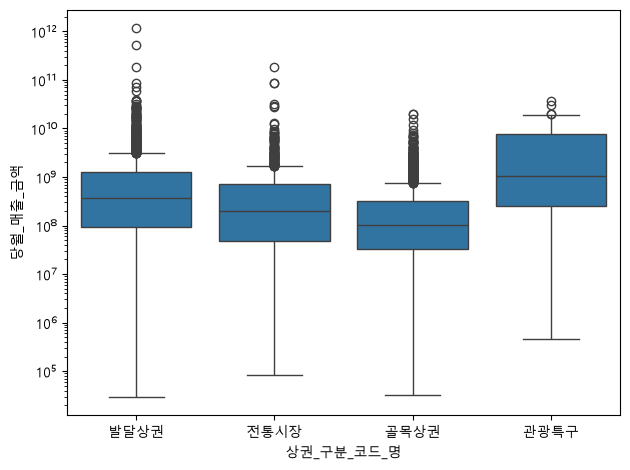

In [ ]:
order = ['발달상권', '전통시장', '골목상권', '관광특구']
sns.boxplot(data=df,
            x='상권_구분_코드_명',
            y='당월_매출_금액',
            order=order)

plt.yscale("log")   # y축 로그 만드는 이유: 큰 차이를 줄여줌.
plt.tight_layout()
plt.show()